In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("ipl_match_details.csv.zip")

In [5]:
df

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
0,335982,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
1,335982,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
2,335982,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
3,335982,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
4,335982,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193463,1237181,1,12,5,RR Pant,SS Iyer,NM Coulter-Nile,0,0,0,0,0,NaN,NaN,NaN,NaN,Delhi Capitals,Mumbai Indians
193464,1237181,1,12,6,RR Pant,SS Iyer,NM Coulter-Nile,1,0,1,0,0,NaN,NaN,NaN,NaN,Delhi Capitals,Mumbai Indians
193465,1237181,1,13,1,RR Pant,SS Iyer,KH Pandya,0,1,1,0,0,NaN,NaN,NaN,wides,Delhi Capitals,Mumbai Indians
193466,1237181,1,13,2,RR Pant,SS Iyer,KH Pandya,1,0,1,0,0,NaN,NaN,NaN,NaN,Delhi Capitals,Mumbai Indians


### 2 — Basic Inspection

#### Quick dataset overview.

In [6]:
df.head()

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
0,335982,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
1,335982,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
2,335982,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
3,335982,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
4,335982,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore


In [7]:
df.shape

(193468, 18)

In [9]:
df.columns

Index(['id', 'inning', 'over', 'ball', 'batsman', 'non_striker', 'bowler',
       'batsman_runs', 'extra_runs', 'total_runs', 'non_boundary', 'is_wicket',
       'dismissal_kind', 'player_dismissed', 'fielder', 'extras_type',
       'batting_team', 'bowling_team'],
      dtype='str')

### Data Types

In [11]:
df.dtypes

id                  int64
inning              int64
over                int64
ball                int64
batsman               str
non_striker           str
bowler                str
batsman_runs        int64
extra_runs          int64
total_runs          int64
non_boundary        int64
is_wicket           int64
dismissal_kind        str
player_dismissed      str
fielder               str
extras_type           str
batting_team          str
bowling_team          str
dtype: object

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 193468 entries, 0 to 193467
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   id                193468 non-null  int64
 1   inning            193468 non-null  int64
 2   over              193468 non-null  int64
 3   ball              193468 non-null  int64
 4   batsman           193468 non-null  str  
 5   non_striker       193468 non-null  str  
 6   bowler            193468 non-null  str  
 7   batsman_runs      193468 non-null  int64
 8   extra_runs        193468 non-null  int64
 9   total_runs        193468 non-null  int64
 10  non_boundary      193468 non-null  int64
 11  is_wicket         193468 non-null  int64
 12  dismissal_kind    9495 non-null    str  
 13  player_dismissed  9495 non-null    str  
 14  fielder           6784 non-null    str  
 15  extras_type       10233 non-null   str  
 16  batting_team      193468 non-null  str  
 17  bowling_team      193

In [13]:
df.describe()

,id,inning,over,ball,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket
count,1.934680e+05,193468.000000,193468.000000,193468.000000,193468.000000,193468.000000,193468.000000,193468.000000,193468.000000
mean,7.567688e+05,1.482131,9.177027,3.615967,1.240231,0.066414,1.306645,0.000083,0.049078
std,3.060971e+05,0.499682,5.676848,1.807128,1.610867,0.339991,1.598802,0.009094,0.216031
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.012270e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.292970e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000,0.000000
75%,1.082628e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000,0.000000
max,1.237181e+06,2.000000,19.000000,9.000000,6.000000,7.000000,7.000000,1.000000,1.000000


In [14]:
df.isnull().sum()

id                       0
inning                   0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
batsman_runs             0
extra_runs               0
total_runs               0
non_boundary             0
is_wicket                0
dismissal_kind      183973
player_dismissed    183973
fielder             186684
extras_type         183235
batting_team             0
bowling_team           191
dtype: int64

In [15]:
(df.isnull().sum()/df.shape[0])*100

id                   0.000000
inning               0.000000
over                 0.000000
ball                 0.000000
batsman              0.000000
non_striker          0.000000
bowler               0.000000
batsman_runs         0.000000
extra_runs           0.000000
total_runs           0.000000
non_boundary         0.000000
is_wicket            0.000000
dismissal_kind      95.092212
player_dismissed    95.092212
fielder             96.493477
extras_type         94.710753
batting_team         0.000000
bowling_team         0.098724
dtype: float64

## Step 2. Duplicate Analysis 

In [17]:
df.duplicated().sum()

np.int64(1)

# Univarite Analysis 

<Axes: xlabel='inning', ylabel='count'>

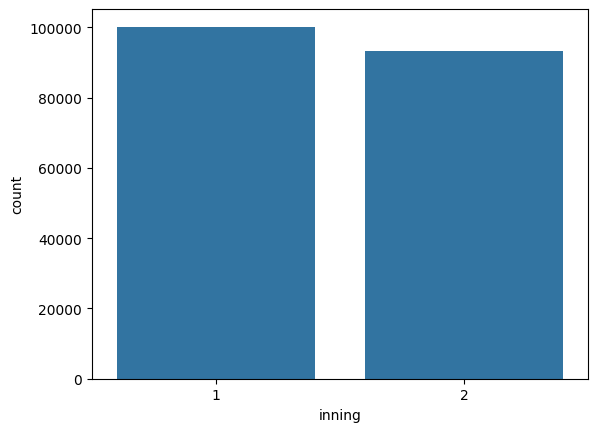

In [18]:
sns.countplot(x=df['inning'])

<Axes: xlabel='batsman_runs', ylabel='count'>

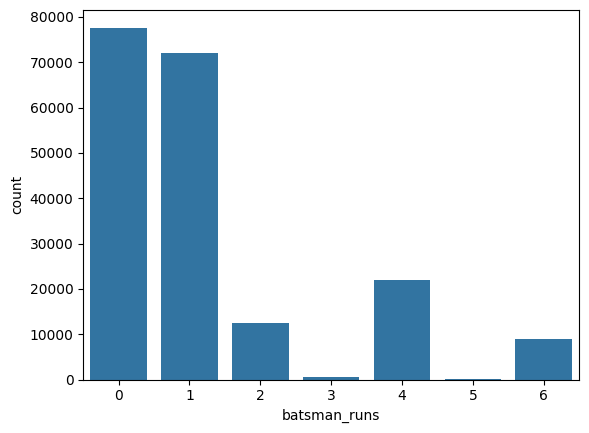

In [21]:
sns.countplot(x=df['batsman_runs'])

In [22]:
df['batsman_runs'].value_counts()

batsman_runs
0    77637
1    71937
4    21908
2    12408
6     8902
3      616
5       60
Name: count, dtype: int64

<Axes: >

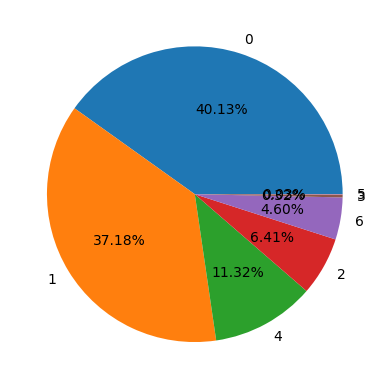

In [23]:
df['batsman_runs'].value_counts().plot(
kind='pie',
autopct='%.2f%%'
)

<Axes: xlabel='batsman_runs', ylabel='Count'>

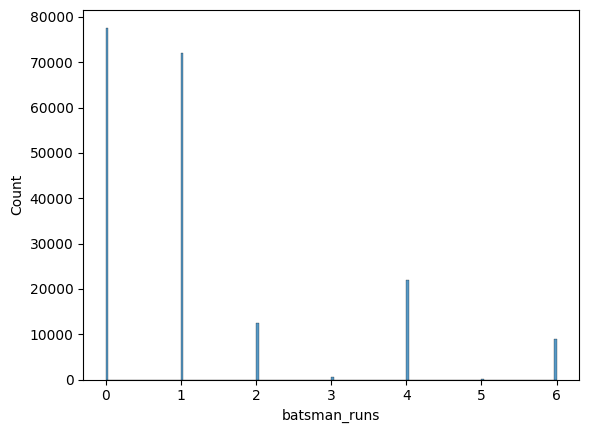

In [24]:
sns.histplot(df['batsman_runs'])

<Axes: xlabel='batsman_runs', ylabel='Count'>

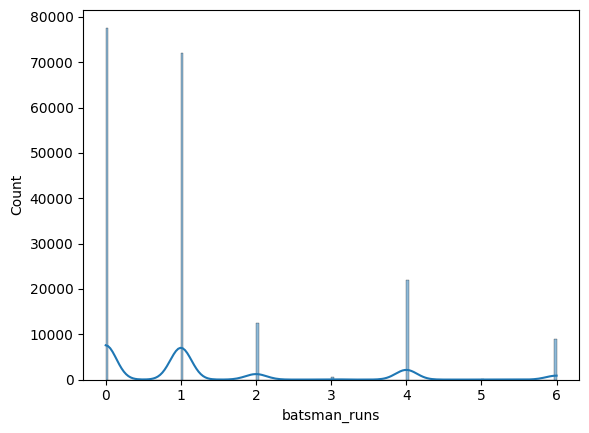

In [25]:
sns.histplot(
df['batsman_runs'],
kde=True
)

<Axes: xlabel='batsman_runs'>

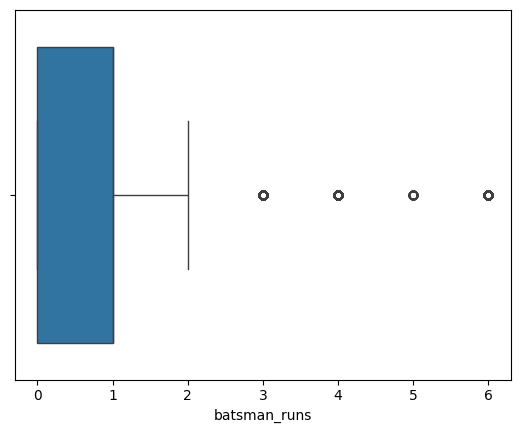

In [27]:
sns.boxplot(x=df['batsman_runs'])

In [28]:
df['batsman_runs'].skew()

np.float64(1.5869112546438768)

## Outlier Detection

<Axes: ylabel='batsman_runs'>

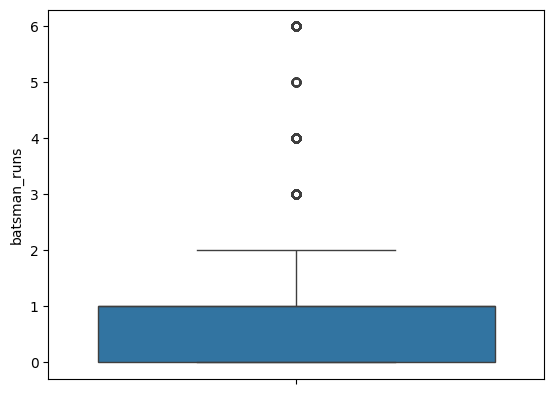

In [29]:
sns.boxplot(df['batsman_runs'])

In [31]:
Q1=df['batsman_runs'].quantile(0.25)

Q3=df['batsman_runs'].quantile(0.75)

IQR=Q3-Q1
IQR

np.float64(1.0)

In [33]:
upper=Q3+1.5*IQR
upper

np.float64(2.5)

In [34]:
lower=Q1-1.5*IQR
lower

np.float64(-1.5)

### Second Example

<Axes: xlabel='batsman', ylabel='count'>

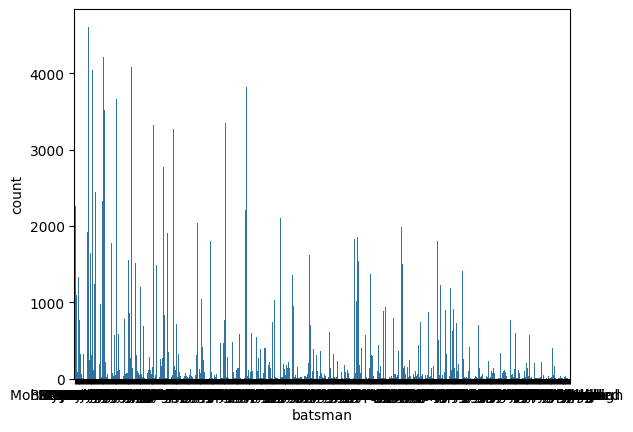

In [38]:
sns.countplot(x=df['batsman'])


<Axes: xlabel='count', ylabel='batsman'>

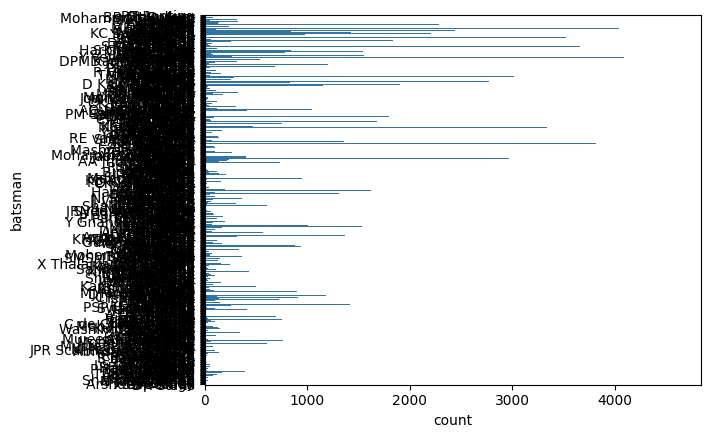

In [36]:
sns.countplot(df['batsman'])